# The pattern that measures itself off its own overshoot 🔑
### The Cypher harmonic — five dots, a 78.6% retracement of an *extended* leg, and a stopwatch

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_a_placebo%3F: Busted](https://img.shields.io/badge/Beats_a_placebo%3F-Busted-8b949e?style=flat-square)

Of all the "harmonic patterns" retail charting software draws for you, the **Cypher** is the odd one out: instead of projecting its reversal point D from the *original* X-A swing (like the Gartley, Bat, Butterfly and Crab all do), it lets point C **overshoot** the pattern's own high or low, then measures D as a **78.6% retracement of that freshly-extended leg**. Proponents pitch it as a higher-win-rate filter precisely because that extra overshoot step supposedly screens out weaker setups.

So we built a robot that finds every Cypher on six liquid tapes over the last 21-25 years — no eyeballing, no cherry-picking — and asked whether fading price right where the pattern says to would actually have made money.

> 📓 **Plain-language layer.** Want the *t*-stats, the Bonferroni correction and the placebo math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** Pivots are a confirmed percentage zig-zag (known only after price reverses enough to lock them in — no look-ahead). Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from cypher_harmonic import data, strategy as st

PCT = 0.02
HAVE_REAL = data.have_real()
BARS = data.load_basket() if HAVE_REAL else {}
print("real cache present:", HAVE_REAL, "| basket:", data.BASKET)

# frozen headline numbers (mirror of docs/results.md)
R = {'basket': ('SPY', 'QQQ', 'AAPL', 'MSFT', 'TSLA', 'NVDA'), 'asof': '2026-06-30', 'n_pivots': 6055, 'n_cand_cyp': 153, 'n_cyp': 127, 'n_cand_plac': 153, 'n_plac': 134, 'cyp': {1: {'hit': 57.5, 'mean': 22.89, 't': 1.08}, 5: {'hit': 50.4, 'mean': 45.77, 't': 0.84}, 10: {'hit': 52.0, 'mean': 27.69, 't': 0.34}}, 'wilson_cyp': (41.8, 58.9), 'per_instrument': {'SPY': {'n': 21, 'mean': -59.62, 't': -1.19}, 'QQQ': {'n': 18, 'mean': 60.34, 't': 0.79}, 'AAPL': {'n': 16, 'mean': 128.81, 't': 1.33}, 'MSFT': {'n': 15, 'mean': 28.98, 't': 0.24}, 'TSLA': {'n': 26, 'mean': 77.68, 't': 0.64}, 'NVDA': {'n': 31, 'mean': 47.21, 't': 0.24}}, 'base': {1: {'mean': -4.78, 't': 0.99}, 5: {'mean': -2.83, 't': 0.81}, 10: {'mean': -8.35, 't': 0.43}}, 'n_base': 2540, 'base_per_instrument': {'SPY': {'base_mean': -15.57, 't': -1.06}, 'QQQ': {'base_mean': 19.17, 't': 0.51}, 'AAPL': {'base_mean': -29.94, 't': 1.34}, 'MSFT': {'base_mean': -18.22, 't': 0.39}, 'TSLA': {'base_mean': -42.76, 't': 0.79}, 'NVDA': {'base_mean': 47.93, 't': -0.0}}, 'bonf_n_tests': 7, 'bonf_thr': 2.69, 'bonf_uncorrected': 0, 'bonf_survive': 0, 'timer': {1: {'gross': 22.89, 't_gross': 1.08, 'net5': 12.89, 't5': 0.61, 'net10': 2.89, 't10': 0.14}, 3: {'gross': 27.93, 't_gross': 0.72, 'net5': 17.93, 't5': 0.47, 'net10': 7.93, 't10': 0.21}, 5: {'gross': 45.77, 't_gross': 0.84, 'net5': 35.77, 't5': 0.66, 'net10': 25.77, 't10': 0.47}, 10: {'gross': 27.69, 't_gross': 0.34, 'net5': 17.69, 't5': 0.22, 'net10': 7.69, 't10': 0.09}, 20: {'gross': -12.92, 't_gross': -0.12, 'net5': -22.92, 't5': -0.21, 'net10': -32.92, 't10': -0.31}}, 'plac': {1: {'mean': 1.82, 't': 0.58}, 5: {'mean': 86.98, 't': -0.52}, 10: {'mean': 91.39, 't': -0.54}}, 'plac_per_instrument': {'SPY': {'n': 23, 'mean': 29.16, 'beats': False}, 'QQQ': {'n': 21, 'mean': 101.24, 'beats': False}, 'AAPL': {'n': 16, 'mean': -44.18, 'beats': True}, 'MSFT': {'n': 15, 'mean': 17.81, 'beats': True}, 'TSLA': {'n': 25, 'mean': 12.86, 'beats': True}, 'NVDA': {'n': 34, 'mean': 264.03, 'beats': False}}, 'n_beats_plac': 3, 'syn_null_mean': 0.13, 'syn_null_sd': 0.86, 'syn_null_fire': 0, 'syn_null_seeds': 20, 'syn_planted_n': 216, 'syn_planted_mean': 99.57, 'syn_planted_t': 5.91, 'fp': {'SPY': '4ae3283c45e5', 'QQQ': 'f0c763128acf', 'AAPL': 'c5c7b7855e9b', 'MSFT': 'c7a24ba85055', 'TSLA': 'f8ca92e420b8', 'NVDA': 'fd06322c7266'}}


real cache present: True | basket: ('SPY', 'QQQ', 'AAPL', 'MSFT', 'TSLA', 'NVDA')


## The answer first

| Question | Answer |
|---|---|
| Does price turn where the Cypher says it should? | **Barely, and not provably.** Over a 5-day hold the pattern averages **+46 bps** — a small positive number with a hit rate landing *exactly* on a coin flip (50.4%), and the *t*-stat (**0.84**) is nowhere near the bar for calling it real. |
| Does it beat what a random trade would have earned? | **Not provably.** Against a random-day baseline matched to the same bullish/bearish mix, the gap is Welch *t* = **0.81** — comfortably inside noise. |
| Does the specific 78.6%-of-XC ratio matter? | **No detectable sign of it.** Swap that number for a random retracement on the *identical* pivots and, at the pooled level, the random version actually does *better* (Welch *t* = -0.52). |
| Can you trade it? | **No.** Every hold length is weak before costs and turns net-negative by 20 days. |

> A pattern marketed as a sharper filter than its harmonic cousins turns out, on the real tape, to be statistically indistinguishable from a coin flip that occasionally loses to its own placebo.

## 1 · The claim

> *"Find four swing points X-A-B-C. If B retraces **38-62%** of the X-A move, let C **overshoot the original A swing** by **113-141%** of X-A — further than a normal pullback would ever go — then project a fifth point D that retraces **78.6%** of that *new, extended* X-C leg. The overshoot-then-retrace shape marks an unusually precise reversal zone: tighter and more selective than the Gartley or Bat."*

That's the Cypher, generally credited to trader Darren Oglesbee and absorbed into Scott Carney's broader "harmonic trading" system alongside the Gartley, Bat, Butterfly and Crab. Its selling point is specificity: while every sibling pattern measures D off the *original* X-A leg, the Cypher's D references the *C point itself* — a level that doesn't even exist until the pattern has already overshot. It's baked into TradingView, MetaTrader and Thinkorswim's auto-scanners as one of the named "harmonic" shapes.

## 2 · So what?

If a pattern this specific — a two-step overshoot-then-retrace chained across four historical swings — genuinely forecasts a turn, and does so more reliably than its simpler cousins, that's a striking, calculator-testable crack in market efficiency. And harmonic trading is popular *precisely* because the charts look uncanny after the fact: hindsight makes any completed pattern look inevitable.

The trap is exactly that hindsight. A trader hand-labelling swings on a chart, with the benefit of already knowing what happened next, will always find the Cypher that worked. So we removed the human: a mechanical rule finds every qualifying X-A-B-C on the tape, in real time, with no knowledge of the future — then we measure what actually happened at D.

## 3 · How would we even know?

- **The basket.** SPY, QQQ, AAPL, MSFT, TSLA, NVDA — six liquid names, daily bars, 2001/2010 → 2026-06-30.
- **The rule, mechanically.** A confirmed zig-zag finds swing pivots (only known once price has reversed enough to lock them in). Every qualifying X-A-B-C (with C overshooting A) projects a D level; we scan forward up to 120 sessions for the first touch.
- **The trade.** Fade at the touch — bet on the reversal the pattern predicts — and measure the forward return.
- **Two honest baselines, announced up front.** (1) A **random-day base rate**: same ticker, same number of trades, same bullish/bearish mix, just on random days — kills the "stocks drift up anyway" confound. (2) A **placebo retracement zone**: the identical pivots, but with the 78.6% number replaced by a random one — kills the "any retracement of the extended leg would work" confound. And because we test six tickers, we **correct for that** (Bonferroni) before calling anything real.

## 4 · The teardown — let's actually look

**First, the headline.** Fade the D-touch, hold 5 days, average across every qualifying Cypher on the basket.

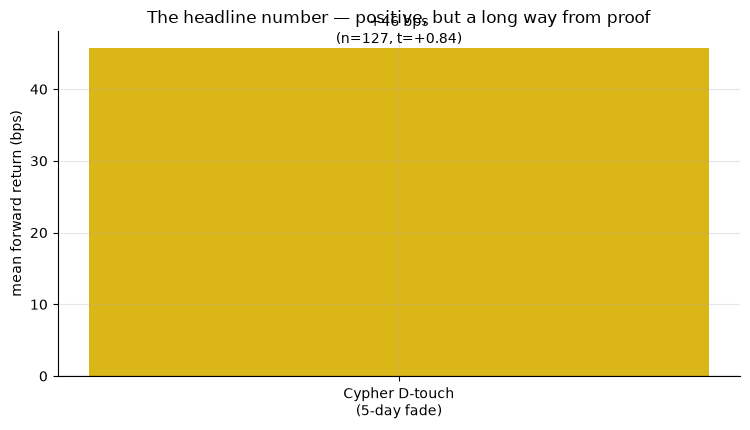

n=127  mean=+45.77bps  t=+0.84


In [2]:
if HAVE_REAL:
    frames = []
    for t in data.BASKET:
        _, _, ledger = st.detect_and_scan(BARS[t], pct=PCT, cost_bps=0.0)
        if not ledger.empty:
            frames.append(ledger)
    CYP = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    s5 = st.summarize(CYP, 'ret_gross_5')
    n5, m5, t5 = s5['n'], s5['mean_bps'], s5['t']
else:
    n5, m5, t5 = R['n_cyp'], R['cyp'][5]['mean'], R['cyp'][5]['t']
fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.bar(['Cypher D-touch\n(5-day fade)'], [m5], color=AMBER, width=.5)
ax.annotate(f'{m5:+.0f} bps\n(n={n5}, t={t5:+.2f})', (0, m5), ha='center',
            va='bottom' if m5 >= 0 else 'top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean forward return (bps)')
ax.set_title('The headline number — positive, but a long way from proof')
plt.tight_layout(); plt.show()
print(f'n={n5}  mean={m5:+.2f}bps  t={t5:+.2f}')

**+46 bps** on average, *t* = **0.84** — positive, but the bar for calling anything real on this desk is *t* ≥ 2, and this is less than half that. Worse, the hit rate is **50.4%** — a coin flip, dead center.

**Second, the honest baseline.** Stocks drift up. A random buy on a random day, matched to the same bullish/bearish mix as our Cypher trades, earns *something* just from that drift (or loses, if the mix leans bearish). Does the Cypher actually add anything on top?

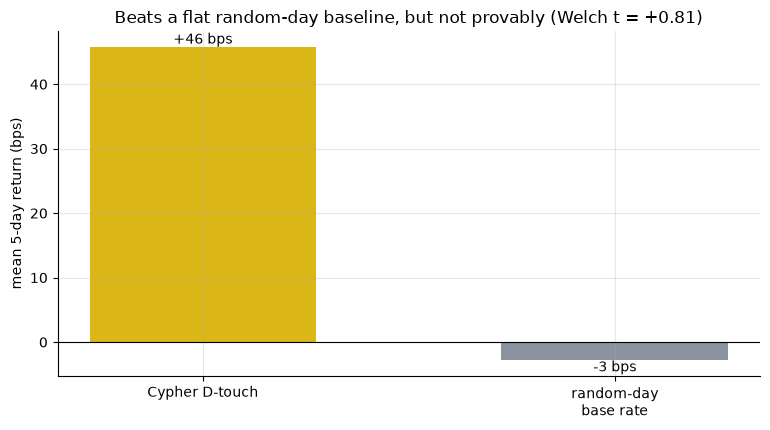

Cypher +45.8 bps vs base rate -2.8 bps  Welch t=+0.81


In [3]:
if HAVE_REAL:
    cyp_by_t, base_frames = {}, []
    for t in data.BASKET:
        _, _, l = st.detect_and_scan(BARS[t], pct=PCT, cost_bps=0.0)
        cyp_by_t[t] = l
        if len(l):
            mix = float((l['reversal_dir'] > 0).mean())
            for s in range(20):
                base_frames.append(st.base_rate_ledger(BARS[t], len(l), mix,
                    seed=st._seed_from(703, t, s)))
    BASE = pd.concat(base_frames, ignore_index=True) if base_frames else pd.DataFrame()
    sb = st.summarize(BASE, 'ret_gross_5')
    bm, wt = sb['mean_bps'], st.welch_t(CYP['ret_gross_5'], BASE['ret_gross_5'])
else:
    bm, wt = R['base'][5]['mean'], R['base'][5]['t']
fig, ax = plt.subplots(figsize=(7.8, 4.4))
ax.bar(['Cypher D-touch', 'random-day\nbase rate'], [m5, bm], color=[AMBER, GREY], width=.55)
for i, v in enumerate([m5, bm]):
    ax.annotate(f'{v:+.0f} bps', (i, v), ha='center', va='bottom' if v>=0 else 'top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean 5-day return (bps)')
ax.set_title(f'Beats a flat random-day baseline, but not provably (Welch t = {wt:+.2f})')
plt.tight_layout(); plt.show()
print(f'Cypher {m5:+.1f} bps vs base rate {bm:+.1f} bps  Welch t={wt:+.2f}')

The Cypher does edge out the random-day baseline in raw terms, but the gap (Welch *t* = **0.81**) is comfortably inside what luck alone could produce. Look at the sample: **127 touches, spread across six stocks, over 21-25 years** — and we tested **six different tickers**.

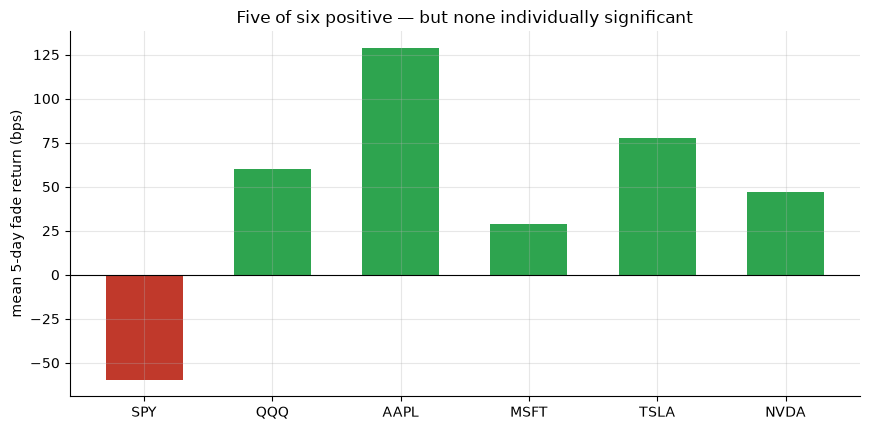

{'SPY': -59.6, 'QQQ': 60.3, 'AAPL': 128.8, 'MSFT': 29.0, 'TSLA': 77.7, 'NVDA': 47.2}


In [4]:
if HAVE_REAL:
    per_t = {t: st.summarize(cyp_by_t[t], 'ret_gross_5') for t in data.BASKET}
    tickers = list(data.BASKET)
    means = [per_t[t]['mean_bps'] for t in tickers]
else:
    tickers = list(R['per_instrument'])
    means = [R['per_instrument'][t]['mean'] for t in tickers]
cols = [GREEN if m > 0 else RED for m in means]
fig, ax = plt.subplots(figsize=(8.8, 4.4))
ax.bar(tickers, means, color=cols, width=.6)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean 5-day fade return (bps)')
ax.set_title('Five of six positive — but none individually significant')
plt.tight_layout(); plt.show()
print({t: round(m,1) for t,m in zip(tickers, means)})

Five of six tickers land positive, but **not one** clears even the naive *t* ≥ 2 bar individually — this is a diffuse, low-conviction average, not a shared mechanism. Correcting properly for having tested six tickers, **0 of 7** results survive.

**Finally, the placebo.** Does the *specific* 78.6% retracement of XC matter, or would any similarly-shaped retracement have done just as well?

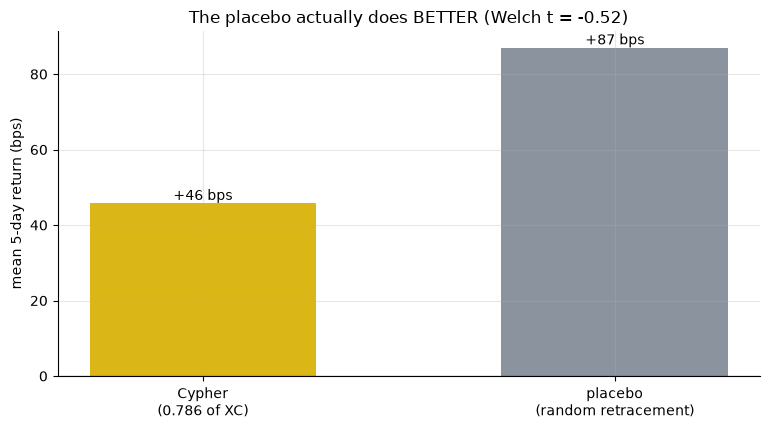

Cypher +45.8 bps vs placebo +87.0 bps  Welch t=-0.52


In [5]:
if HAVE_REAL:
    plac_frames = []
    for t in data.BASKET:
        _, _, lp = st.detect_and_scan(BARS[t], pct=PCT, placebo=True, seed=703, cost_bps=0.0)
        if not lp.empty:
            plac_frames.append(lp)
    PLAC = pd.concat(plac_frames, ignore_index=True) if plac_frames else pd.DataFrame()
    sp = st.summarize(PLAC, 'ret_gross_5')
    pm, wtp = sp['mean_bps'], st.welch_t(CYP['ret_gross_5'], PLAC['ret_gross_5'])
else:
    pm, wtp = R['plac'][5]['mean'], R['plac'][5]['t']
fig, ax = plt.subplots(figsize=(7.8, 4.4))
ax.bar(['Cypher\n(0.786 of XC)', 'placebo\n(random retracement)'], [m5, pm],
       color=[AMBER, GREY], width=.55)
for i, v in enumerate([m5, pm]):
    ax.annotate(f'{v:+.0f} bps', (i, v), ha='center', va='bottom' if v>=0 else 'top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean 5-day return (bps)')
ax.set_title(f'The placebo actually does BETTER (Welch t = {wtp:+.2f})')
plt.tight_layout(); plt.show()
print(f'Cypher {m5:+.1f} bps vs placebo {pm:+.1f} bps  Welch t={wtp:+.2f}')

The placebo — an *arbitrary* retracement of the same extended XC leg — actually earns **more** on average (**+87 bps** vs the Cypher's own **+46 bps**), though the gap (Welch *t* = **-0.52**) is itself not statistically real. The specific number — 78.6% — is not doing detectably better than an arbitrary retracement target would.

## 5 · The verdict

- **Signal — None.** The fade is small and positive (*t* = 0.84), a coin-flip hit rate (50.4%), doesn't beat a matched-direction random day provably (*t* = 0.81), and fails a six-ticker correction (0/7 survive).
- **Tradability — Mirage.** Every hold length is weak before costs and turns net-negative by 20 days.
- **"Is 78.6% of XC the pattern's distinctive signature?" — Busted.** Swap it for a random retracement on the identical pivots and the placebo actually does *better* (Welch *t* = -0.52).

## 6 · Going further 🚪

- **The general lesson: an extra construction step isn't the same as an extra edge.** The Cypher's whole pitch is that overshooting A and then referencing the *new* XC leg makes it a sharper filter than its siblings — on this basket, that extra complexity buys nothing measurable over a coin flip or a randomized control.
- **Sibling studies:** [468-gartley-harmonic](../../468-gartley-harmonic/) (the same 78.6% *number*, but measured off XA, not XC), [699-butterfly-harmonic](../../699-butterfly-harmonic/), [700-bat-harmonic](../../700-bat-harmonic/) and [701-crab-harmonic](../../701-crab-harmonic/) all reach the same shape of verdict independently.

*Think the Cypher needs its full "confluence zone" — several overlapping Fibonacci projections converging near D — to work? Show it beats this study's placebo and survives the multiple-comparison correction, then we'll talk.*